In [ ]:
## Project Purpose

The purpose of this project is to analyze customer shopping behavior and identify patterns in purchasing activity. The project uses data cleaning, exploratory data analysis, and visualization to understand customer demographics, purchasing habits, product preferences, payment methods, discounts, ratings, subscriptions, and other factors related to shopping behavior.


In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
dataset=pd.read_csv("customer_shopping.csv")

In [3]:
# dataset information
first_five=dataset.head()
description=dataset.describe()
information=dataset.info
last_five=dataset.tail()
column=dataset.columns
random_row=dataset.sample()
distinct=dataset.nunique()
dataset["Age"].describe()
dataset["Location"].value_counts()
dataset["Review_Rating"].describe()
dataset["Payment_Method"].value_counts()

Payment_Method
Debit Card        119
Bank Transfer     108
Cash               96
Digital Wallet     89
Credit Card        89
Name: count, dtype: int64

In [4]:
# Handling Missing values
missing=dataset.isnull().sum()
dataset["Age"]=dataset["Age"].fillna(41)
dataset["Age"].isnull().sum()
dataset["Location"]=dataset["Location"].fillna("Unknown")
dataset["Location"].isnull().sum()
dataset["Review_Rating"]=dataset["Review_Rating"].fillna(5)
dataset["Review_Rating"].isnull().sum()
dataset["Payment_Method"]=dataset["Payment_Method"].fillna("Debit card")
dataset["Payment_Method"].isnull().sum()
missing2=dataset.isnull().sum()
dataset["Location"].unique()


<ArrowStringArray>
['Multan', 'Lahore', 'Islamabad', 'Faisalabad', 'Karachi', 'Peshawar',
 'Unknown']
Length: 7, dtype: str

In [5]:
#Handling with duplicates
dataset.duplicated()
dataset=dataset.drop_duplicates()
dataset.duplicated()
dataset.duplicated().sum()


np.int64(0)

In [24]:
#Validation
dataset.nunique()
dataset["Gender"].unique()
dataset["Gender"]=dataset["Gender"].str.capitalize()
dataset["Gender"].unique()
dataset["Location"].unique()
dataset["Product_Category"].unique()
cols=["Item_Purchased","Payment_Method",	"Shipping_Type",	"Purchase_Frequency"]
for i in cols:
    print(i,dataset[i].unique())
dataset["Payment_Method"]=dataset["Payment_Method"].str.replace("Debit Card","Debit card")
dataset.nunique()
dataset["Discount_Percent"].unique()
dataset["Review_Rating"].value_counts()
dataset["Subscription_Status"]=dataset["Subscription_Status"].str.capitalize()
dataset["Subscription_Status"].unique()

Item_Purchased <ArrowStringArray>
[        'Sneakers',         'Keyboard',       'Smartwatch',
         'Cookware',            'Jeans',         'Notebook',
           'Jacket',          'Cushion',          'T-Shirt',
          'Shampoo',       'Face Cream',          'Perfume',
         'Football',      'Cricket Bat',             'Lamp',
    'Running Shoes',            'Novel',       'Headphones',
         'Yoga Mat',       'Smartphone',         'Bedsheet',
         'Lipstick', 'Programming Book',         'Cookbook']
Length: 24, dtype: str
Payment_Method <ArrowStringArray>
['Digital Wallet', 'Credit Card', 'Cash', 'Debit card', 'Bank Transfer']
Length: 5, dtype: str
Shipping_Type <ArrowStringArray>
['Same Day', 'Standard', 'Express']
Length: 3, dtype: str
Purchase_Frequency <ArrowStringArray>
['Monthly', 'Weekly', 'Fortnightly', 'Rarely', 'Quarterly']
Length: 5, dtype: str


<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

In [ ]:
dataset.isnull().sum()
dataset.duplicated()
cols=["Gender",	"Location",	"Product_Category",	"Item_Purchased","Subscription_Status",	"Payment_Method",	"Shipping_Type",	"Purchase_Frequency"]
for i in cols:
     print(i,dataset[i].unique())

In [ ]:
# Product Category Analysis
category_counts = dataset["Product_Category"].value_counts()
print(category_counts)
plt.figure(figsize=(8,5))
plt.bar(category_counts.index, category_counts.values)
plt.xlabel("Product Category")
plt.ylabel("Number of Purchases")
plt.title("Purchases by Product Category")
plt.savefig("Product Category effect")
plt.show()

In [ ]:
#Age Group Analysis
bins = [0, 20, 30, 40, 50, 60, 100]
labels = ["Under 20", "20-29", "30-39", "40-49", "50-59", "60+"]

dataset["Age_Group"] = pd.cut(
    dataset["Age"],
    bins=bins,
    labels=labels
)
age_groups = dataset["Age_Group"].value_counts().sort_index()
plt.bar(age_groups.index, age_groups.values)
plt.xlabel("Age Groups")
plt.ylabel("Number of Purchases")
plt.title("Purchases by different Age Groups")
plt.savefig("Age effect")
plt.show()

In [ ]:
#Gender vs Purchase Amount
gender_purchase = dataset.groupby("Gender")["Purchase_Amount"].mean()
plt.bar(gender_purchase.index, gender_purchase.values)
plt.xlabel("Gender")
plt.ylabel("Number of Purchases")
plt.title("Purchases by different Genders")
plt.savefig("Gender effect")
plt.show()

In [ ]:
#Discount vs Purchase Amount
plt.scatter(
    dataset["Discount_Percent"],
    dataset["Purchase_Amount"]
)

plt.xlabel("Discount Percentage")
plt.ylabel("Purchase Amount")
plt.title("Discount vs Purchase Amount")
plt.savefig("Discount vs purschased amount")
plt.show()

In [ ]:
#Subscription Status
subscription_purchase = dataset.groupby(
    "Subscription_Status"
)["Purchase_Amount"].mean()
plt.bar(subscription_purchase.index, subscription_purchase.values)
plt.xlabel("Subscription")
plt.ylabel("Number of Purchases")
plt.title("Subscription Purchased effect")
plt.savefig("Subscription purchased")
plt.show()


In [ ]:
#Payment Method
payment_counts = dataset["Payment_Method"].value_counts()
plt.bar(payment_counts.index, payment_counts.values)
plt.xlabel("Payment method")
plt.ylabel("Number of Purchases")
plt.title("Payment method used ")
plt.savefig("Payment method used")
plt.show()

In [ ]:
#Location Analysis
location_purchase = dataset.groupby(
    "Location"
)["Purchase_Amount"].mean()
plt.bar(location_purchase.index, location_purchase.values)
plt.xlabel("Location")
plt.ylabel("Number of Purchases")
plt.title("Location effect on purchased amount")
plt.savefig("location effect")
plt.show()


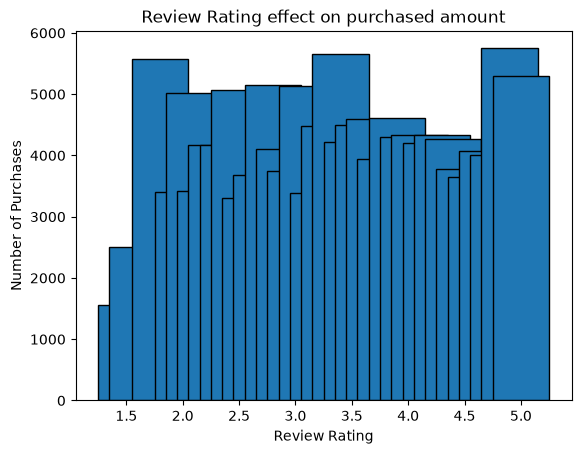

In [41]:
#Review Rating vs Purchase Amount
rating_purchase = dataset.groupby(
    "Review_Rating"
)["Purchase_Amount"].mean()
plt.bar(rating_purchase.index, rating_purchase.values,edgecolor="black",width=0.5,linewidth=1)
plt.xlabel("Review Rating")
plt.ylabel("Number of Purchases")
plt.title("Review Rating effect on purchased amount")
plt.savefig("Review rating effect")
plt.show()


In [ ]:
#Previous Purchases
plt.scatter(
    dataset["Previous_Purchases"],
    dataset["Purchase_Amount"]
)

plt.xlabel("Previous Purchases")
plt.ylabel("Purchase Amount")
plt.title("Previous Purchases vs Purchase Amount")
plt.savefig("Previous purchased")
plt.show()

In [ ]:
## Conclusion

This project analyzed customer shopping behavior using data cleaning, validation, exploratory data analysis, and visualization. The analysis explored purchasing patterns across product categories, customer demographics, payment methods, subscription status, discounts, ratings, locations, and previous purchases.

The results helped identify important patterns in customer purchasing behavior and provided a better understanding of how different customer and transaction-related factors are distributed in the dataset.

Overall, the project provided practical experience in preparing real-world-style data, validating data quality, performing exploratory analysis, creating visualizations, and communicating data-driven insights.
